<a href="https://colab.research.google.com/github/vision123-hub/machine-learning/blob/main/email_spam_detection_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EMAIL SPAM DETECTION

Dataset:
    Links  Words  Capital_Letters  Promotional_Words  Spam
0       0    120                3                  0     0
1       1    150                5                  0     0
2       0    100                2                  0     0
3       2    130                4                  0     0
4       1    160                6                  0     0
5       5     50               25                  1     1
6       7     45               30                  1     1
7       6     60               20                  1     1
8       8     40               35                  1     1
9       4     55               22                  1     1
10      0    110                4                  0     0
11      1    140                3                  0     0
12      2    125                5                  0     0
13      0    180                2                  0     0
14      1    100                6                  0     0
15      9     35         

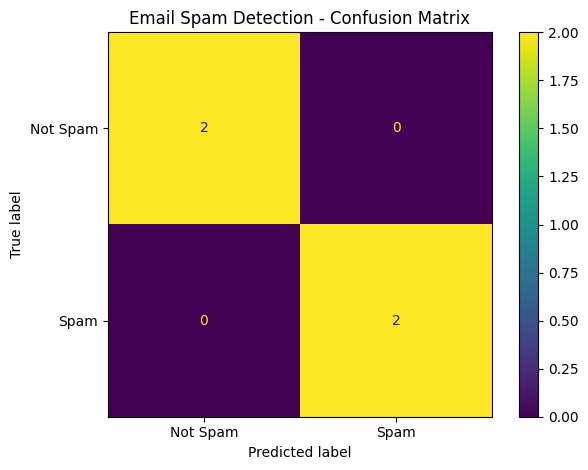

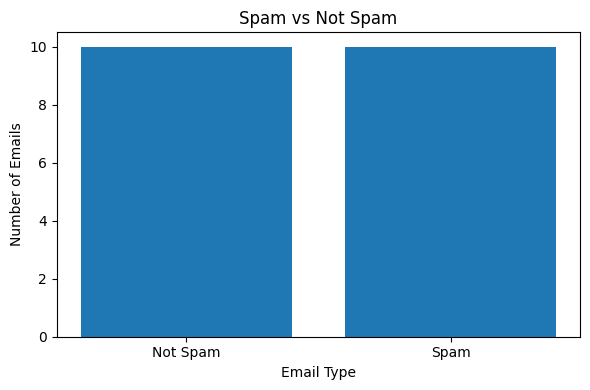

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

data = {
    "Links": [0, 1, 0, 2, 1, 5, 7, 6, 8, 4, 0, 1, 2, 0, 1, 9, 6, 5, 8, 7],
    "Words": [
        120,
        150,
        100,
        130,
        160,
        50,
        45,
        60,
        40,
        55,
        110,
        140,
        125,
        180,
        100,
        35,
        55,
        65,
        45,
        50,
    ],
    "Capital_Letters": [
        3,
        5,
        2,
        4,
        6,
        25,
        30,
        20,
        35,
        22,
        4,
        3,
        5,
        2,
        6,
        40,
        28,
        25,
        32,
        30,
    ],
    "Promotional_Words": [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
    "Spam": [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
}

df = pd.DataFrame(data)

print("EMAIL SPAM DETECTION")
print("====================")

print("\nDataset:")
print(df)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["Spam"].value_counts())

X = df[["Links", "Words", "Capital_Letters", "Promotional_Words"]]
y = df["Spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nActual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test, y_pred, target_names=["Not Spam", "Spam"], zero_division=0
    )
)

coefficients = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_[0]})

print("\nModel Coefficients:")
print(coefficients)

new_email = pd.DataFrame(
    {"Links": [6], "Words": [50], "Capital_Letters": [25], "Promotional_Words": [1]}
)

prediction = model.predict(new_email)
probability = model.predict_proba(new_email)

print("\nNew Email:")
print(new_email)

print("\nSpam Probability:", round(probability[0][1] * 100, 2), "%")

if prediction[0] == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: NOT SPAM")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Spam", "Spam"])

disp.plot()
plt.title("Email Spam Detection - Confusion Matrix")
plt.tight_layout()
plt.show()

class_counts = df["Spam"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Not Spam", "Spam"], class_counts.values)
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")
plt.title("Spam vs Not Spam")
plt.tight_layout()
plt.show()
